# Name :   Mohd Kaif
# Reg.no : 24-27-32
# M.Tech(Data Science)
# Assignment III

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from scipy import stats

# Ques 1.

Write a function that takes input (x,y) and returns MLE theta using Normal Equation.
Use numpy in python to implement. Create a feature set x using linspace or np.random
function and target values y. Call the function by passing these arguments and plot the
precited values against input data.

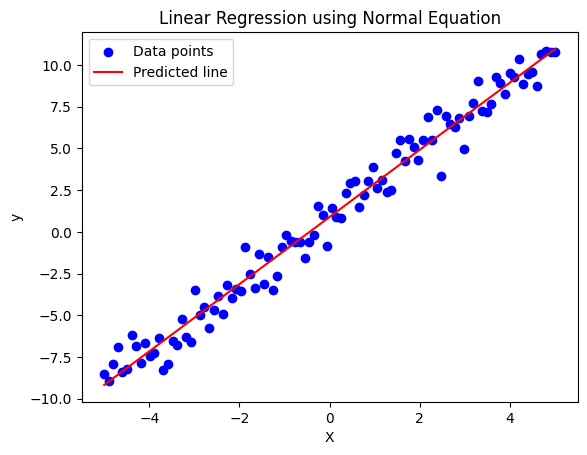

In [19]:
def normal_equation_mle(X, y):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

np.random.seed(42)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = 2 * X + 1 + np.random.normal(0, 1, (100, 1)) 

theta = normal_equation_mle(X, y)

X_b = np.c_[np.ones((X.shape[0], 1)), X]
y_pred = X_b.dot(theta)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label='Predicted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression using Normal Equation')
plt.legend()
plt.show()

# Ques 2.

Write a program to implement polynomial regression and compare it with the result obtained in the last question by plotting both the hypothesis

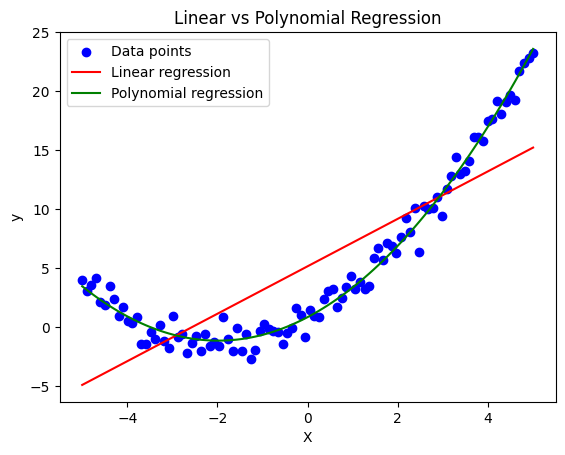

In [20]:
def polynomial_regression(X, y, degree=2):
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly_features.fit_transform(X)

    X_b = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]

    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta, poly_features

np.random.seed(42)
X = np.linspace(-5, 5, 100).reshape(-1, 1)
y = 1 + 2*X + 0.5*X**2 + np.random.normal(0, 1, (100, 1))  

theta_linear = normal_equation_mle(X, y)
theta_poly, poly_features = polynomial_regression(X, y, degree=2)

X_b = np.c_[np.ones((X.shape[0], 1)), X]
y_pred_linear = X_b.dot(theta_linear)

X_poly = poly_features.fit_transform(X)
X_b_poly = np.c_[np.ones((X_poly.shape[0], 1)), X_poly]
y_pred_poly = X_b_poly.dot(theta_poly)

plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred_linear, color='red', label='Linear regression')
plt.plot(X, y_pred_poly, color='green', label='Polynomial regression')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear vs Polynomial Regression')
plt.legend()
plt.show()

# Ques 3.

Access the effects of Outliers while training a linear regression by introducing some outlier in the data. Propose a solution how these outliers can be detected and removed before training the model. Implement the solution in python.

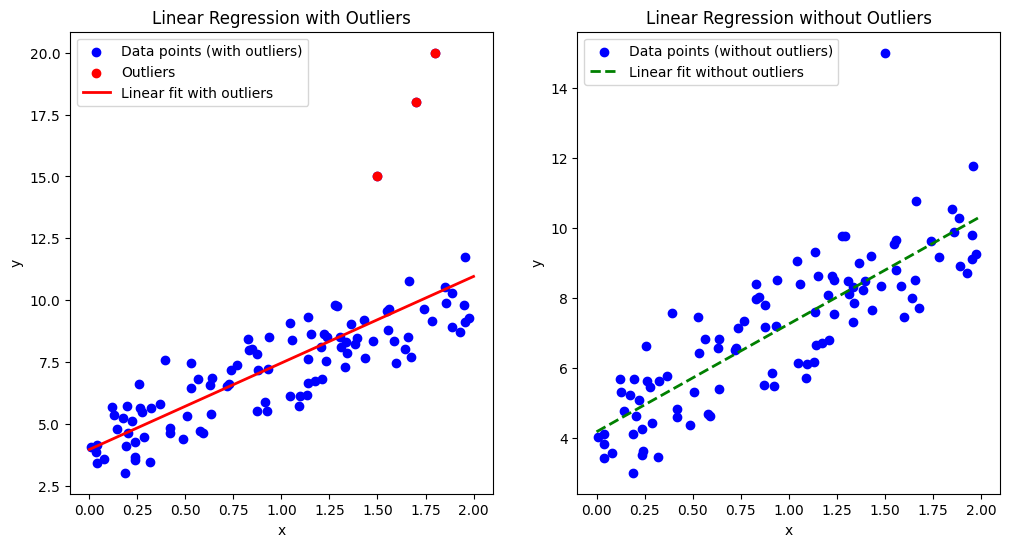

In [22]:
def mle_theta(X, y):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
    return theta

np.random.seed(0)
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) 

X_outliers = np.array([[1.5], [1.7], [1.8]])
y_outliers = np.array([[15], [18], [20]])
X = np.vstack((X, X_outliers))
y = np.vstack((y, y_outliers))

def remove_outliers(X, y):
    z_scores = np.abs(stats.zscore(y))
    threshold = 3
    non_outliers = (z_scores < threshold).flatten()
    return X[non_outliers], y[non_outliers]

theta_with_outliers = mle_theta(X, y)
X_clean, y_clean = remove_outliers(X, y)
theta_without_outliers = mle_theta(X_clean, y_clean)

X_new = np.linspace(0, 2, 100).reshape(100, 1)
X_new_b = np.c_[np.ones((100, 1)), X_new]
y_predict_with_outliers = X_new_b.dot(theta_with_outliers)
y_predict_without_outliers = X_new_b.dot(theta_without_outliers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(X, y, color="blue", label="Data points (with outliers)")
ax1.scatter(X_outliers, y_outliers, color="red", label="Outliers")
ax1.plot(X_new, y_predict_with_outliers, "r-", linewidth=2, label="Linear fit with outliers")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Linear Regression with Outliers")
ax1.legend()

ax2.scatter(X_clean, y_clean, color="blue", label="Data points (without outliers)")
ax2.plot(X_new, y_predict_without_outliers, "g--", linewidth=2, label="Linear fit without outliers")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.set_title("Linear Regression without Outliers")
ax2.legend()

plt.show()


For Outlier Detection : We calculate the Z-score of each 𝑦 value. If the Z-score is greater than a threshold (usually 3), that data point is marked as an outlier.

After filtering out the outliers, we plot both the linear fit with outliers and the fit without them to observe the effects of outliers on the model.


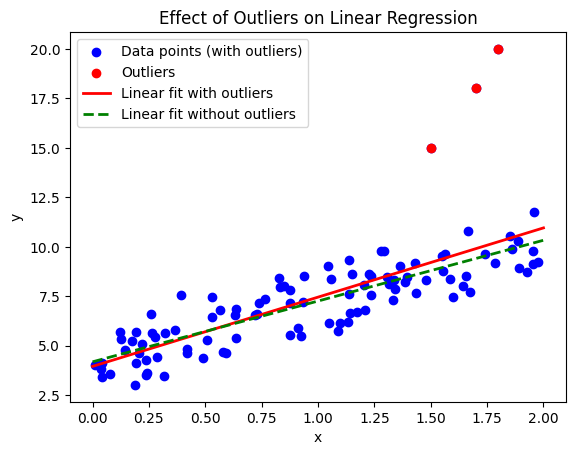

In [23]:
X_new = np.linspace(0, 2, 100).reshape(100, 1)
X_new_b = np.c_[np.ones((100, 1)), X_new]
y_predict_with_outliers = X_new_b.dot(theta_with_outliers)
y_predict_without_outliers = X_new_b.dot(theta_without_outliers)

plt.scatter(X, y, color="blue", label="Data points (with outliers)")
plt.scatter(X_outliers, y_outliers, color="red", label="Outliers")
plt.plot(X_new, y_predict_with_outliers, "r-", linewidth=2, label="Linear fit with outliers")
plt.plot(X_new, y_predict_without_outliers, "g--", linewidth=2, label="Linear fit without outliers")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Effect of Outliers on Linear Regression")
plt.show()
